<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter05_%ED%9A%8C%EA%B7%80_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic (1).ttf


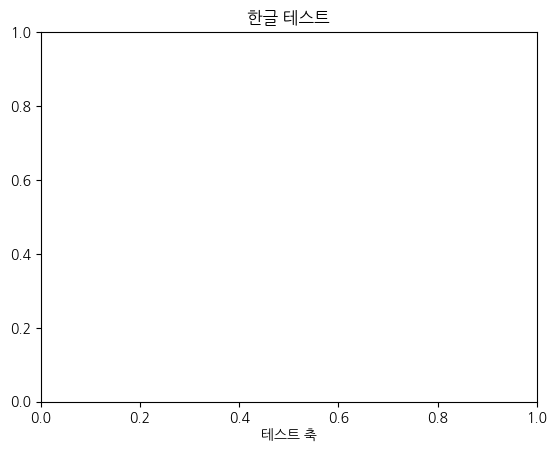

In [6]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

### 경사 하강법(Gradient Descent)

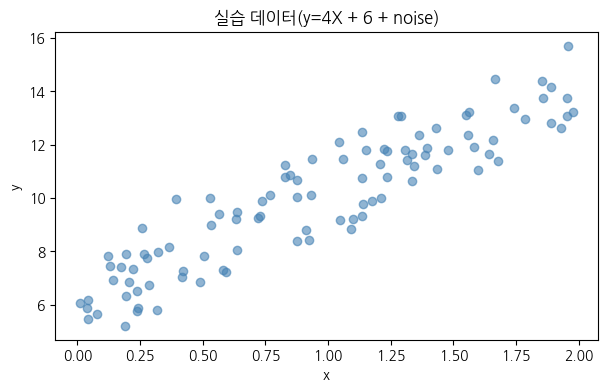

X shape: (100, 1) y shape: (100, 1)


In [7]:
import numpy as np
#실습용 데이터 생성: y=4X + 6 + 노이즈
#경사 하강법으로 실제 관계식(w1=4, w0=6)을 스스로 찾아내는 것
np.random.seed(0)
X=2*np.random.rand(100,1) #0~2 사이에 균등분포 랜덤값 100
y=6+4*X+np.random.randn(100,1) #평균이 0이고 표준 편차가 1인 정규 분포를 따르는 실수 난수 100개

plt.figure(figsize=(7,4))
plt.scatter(X,y,alpha=0.6, color='steelblue')
plt.title('실습 데이터(y=4X + 6 + noise)')
plt.xlabel('x'); plt.ylabel('y')
plt.show()
print('X shape:',X.shape, 'y shape:', y.shape)

In [8]:
#경사 하강법(Gradient Descent)
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
  N = len(y)
  w1_update = np.zeros_like(w1) #w1과 동일한 shape의 0 배열로 초기화
  w0_update = np.zeros_like(w0)

  #예측값 계산: ŷ = X·w1ᵀ + w0 , y = 4X + 6
  y_pred = np.dot(X, w1.T) + w0

  #잔차(Residual): 실제값 - 예측값
  diff = y - y_pred

  #절편(w0) 편미분용 배열
  w0_factors = np.ones((N,1))

  #편미분 계산 후 learning_rate 곱해서 업데이트량 계산
  w1_update = -(2/N) * learning_rate * (np.dot(X.T,diff)) #w1의 기울기 방향, -음수 부호는 기울기 반대 방향으로 이동(최솟값 방향)
  w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T,diff))

  return w1_update, w0_update

w1(기울기): 4.028 w0(절편): 6.156
배치 GD MSE: 0.9937


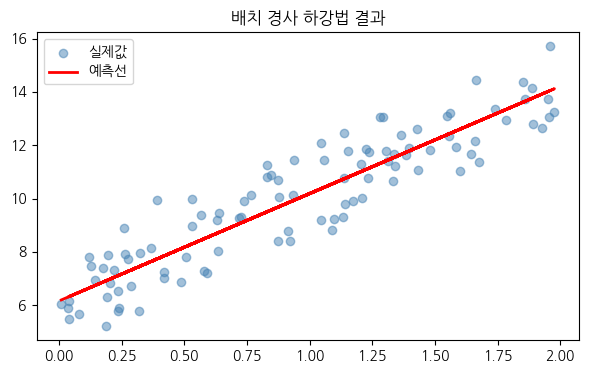

In [9]:
#비용 계산 함수
def get_cost(y, y_pred):
  #MSE(Mean Squared Error) 계산
  #MSE = (1/N) * Σ(y - ŷ)²
  N = len(y)
  cost = np.sum(np.square(y-y_pred))/N
  return cost

#미니배치 확률적 경사 하강법(Mini-batch Stochastic Gradient Descent)
def stochastic_gradient_descent_steps(X, y,batch_size=10, iters=10000):
  #배치 경사 하강법으로 최적 w1, w0 탐색
  w0 = np.zeros((1,1)) #절편 초기값: 0, 1행 1열의 2차원 배열[[0]]
  w1 = np.zeros((1,1)) #기울기 초기값: 0
  #0에서 시작해 점점 실제 w1=4, w0=6으로 수렴
  for ind in range(iters):
    np.random.seed(ind) #매번 다른 랜덤 샘플

    stochastic_random_index = np.random.permutation(X.shape[0]) #0~N-1 인덱스를 무작위로 섞음
    sample_X = X[stochastic_random_index[0:batch_size]]
    sample_y = y[stochastic_random_index[0:batch_size]]

    #전체 데이터 대신 샘플만으로 가중치 업데이트
    w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
    w1 = w1 - w1_update #기울기 반대 방향으로 이동
    w0 = w0 - w0_update
  return w1, w0

#1000번 반복 -> w1는4, w0는6 수렴 확인
w1, w0 = stochastic_gradient_descent_steps(X, y, iters = 1000)
print('w1(기울기): {0:.3f} w0(절편): {1:.3f}'.format(w1[0,0], w0[0,0]))

y_pred = w1[0,0] * X + w0
print(f'배치 GD MSE: {get_cost(y,y_pred):.4f}')

#학습된 직선 시각화
plt.figure(figsize=(7,4))
plt.scatter(X,y,alpha=0.5, color='steelblue',label='실제값')
plt.plot(X,y_pred, color='red',linewidth=2,label='예측선')
plt.title('배치 경사 하강법 결과')
plt.legend();plt.show()

### 사이킷런 LinearRegression - 캘리포니아 주택 가격 예측

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
#캘리포니아 주택 가격 데이터셋
housing = fetch_california_housing()
caliDF = pd.DataFrame(housing.data, columns=housing.feature_names)
caliDF['Price'] = housing.target

print(caliDF.shape)
display(caliDF.head())
print('\n주요 피처 설명:')
print('  MedInc:    가구의 중간 소득 (중요한 예측 변수)')
print('  HouseAge:  주택의 중간 연령')
print('  AveRooms:  가구당 평균 방 개수')
print('  AveBedrms: 가구당 평균 침실 개수')
print('  Population:인구')
print('  AveOccup:  가구당 평균 거주자 수')
print('  Latitude:  위도')
print('  Longitude: 경도')

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



주요 피처 설명:
  MedInc:    가구의 중간 소득 (중요한 예측 변수)
  HouseAge:  주택의 중간 연령
  AveRooms:  가구당 평균 방 개수
  AveBedrms: 가구당 평균 침실 개수
  Population:인구
  AveOccup:  가구당 평균 거주자 수
  Latitude:  위도
  Longitude: 경도


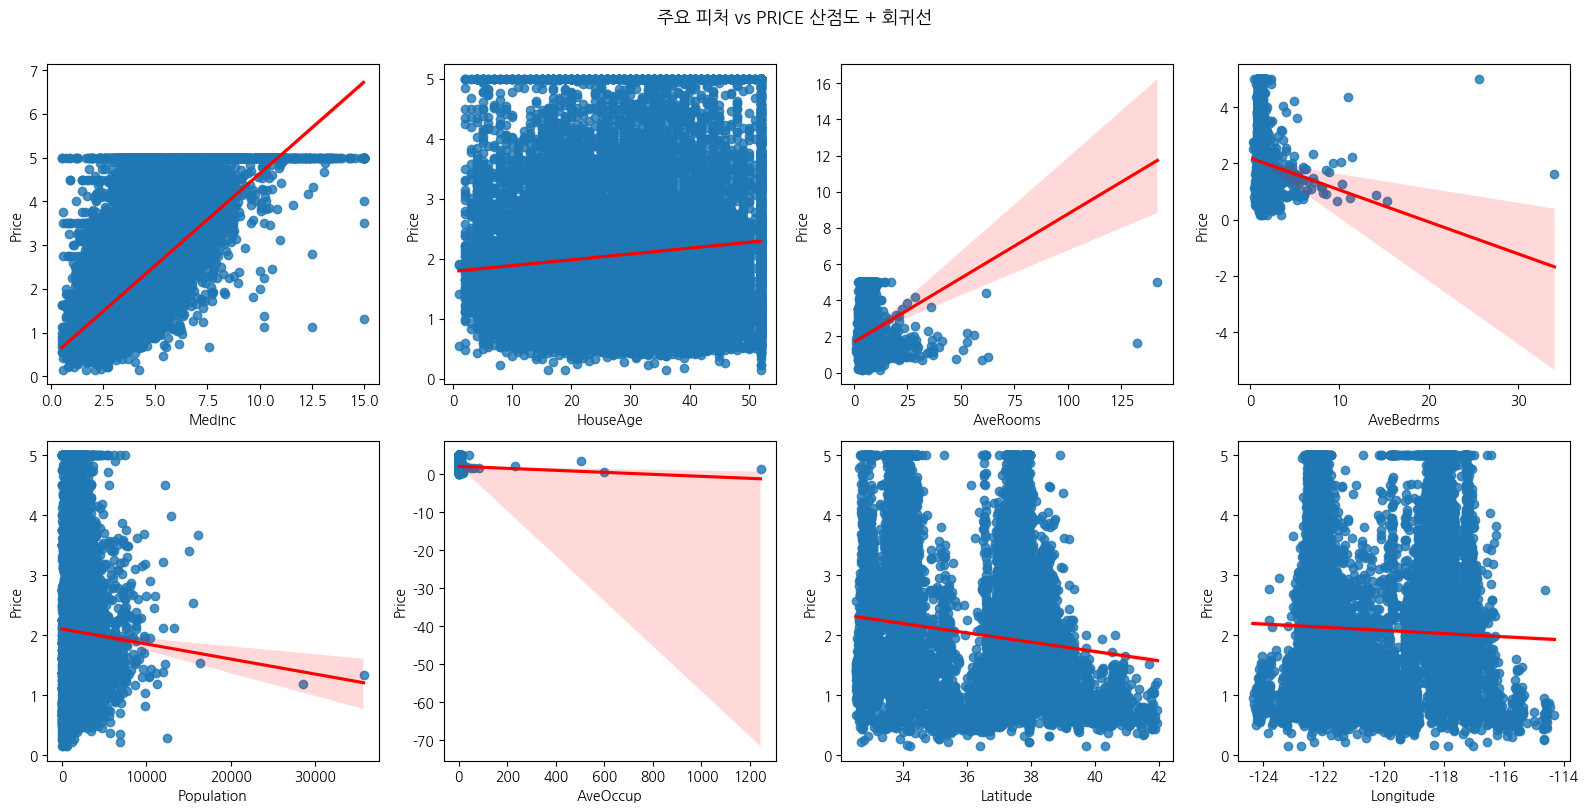

In [12]:
#주요 피처와 PRICE의 관계 산점도 시각화
fig,axs=plt.subplots(figsize=(16,8),ncols=4,nrows=2)
Im_features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
for i, feature in enumerate(Im_features):
  row = int(i/4) #0~3:0행, 4~7: 1행
  col = i%4 #0,1,2,3 반복 : 열 위치
  #산점도(scatter) + 회귀선(regression line) + 신뢰구간을 한번에 그림
  sns.regplot(x=feature,y='Price',data=caliDF,line_kws={'color':'red'},ax=axs[row,col])
plt.suptitle('주요 피처 vs PRICE 산점도 + 회귀선',fontsize=13,y=1.01)
plt.tight_layout()
plt.show()

In [13]:
#선형 회귀 학습/예측/평가
y_target = caliDF['Price']
X_data = caliDF.drop(['Price'], axis=1)

#학습70% / 테스트 30% 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.3, random_state=156
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

In [14]:
#회귀 평가 지표
#MSE: 오차 제곱 평균: 이상치에 민감
mse = mean_squared_error(y_test,y_preds)

#RMSE: MSE의 제곱근
rmse = np.sqrt(mse)

#R²(결정계수): 0~1, 1에 가까울수록 좋음
r2 = r2_score(y_test, y_preds)

print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

print('\n절편(w0):',round(lr.intercept_,2))

#회귀 계수(coefficient): 각 피어가 PRICE에 미치는 영향
coeff = pd.Series(data=np.round(lr.coef_,1), index=X_data.columns)
print('\n회귀 계수 (내림차순):')
print(coeff.sort_values(ascending=False))

MSE: 0.543
RMSE: 0.737
R²: 0.595

절편(w0): -37.24

회귀 계수 (내림차순):
AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64


In [15]:
from sklearn.model_selection import cross_val_score
#K-Fold 교차 검증(Cross-Validation)
lr = LinearRegression()
neg_mse_scores = cross_val_score(lr,X_data, y_target, scoring='neg_mean_squared_error', cv=5)

rmse_scores = np.sqrt(-1*neg_mse_scores) #-1*음수
avg_rmse = np.mean(rmse_scores)
print('5-Fold 개별 RMSE:', np.round(rmse_scores,3))
print('5-Fold 평균 RMSE:', np.round(avg_rmse,3))

5-Fold 개별 RMSE: [0.696 0.789 0.804 0.737 0.703]
5-Fold 평균 RMSE: 0.746


### 다항 회귀 (Polynomial Regression)
[선형 회귀의 한계]
- y = w1*x + w0 → 직선만 표현 가능 → 비선형 관계 포착 불가 [다항 회귀 해결책]
- 입력 피처를 고차항으로 확장 → 선형 모델로 비선형 관계 학습
- [x1, x2] → [1, x1, x2, x1², x1*x2, x2²] (2차 변환)
- 변환 후에는 여전히 선형 회귀로 학습 가능 [PolynomialFeatures 동작]
- degree=2: 1차항 + 2차항 + 교호작용(interaction) 항 자동 생성

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X = np.arange(4).reshape(2,2)
print('원본 피처(2행 X 2열):\n',X)

poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('\n2차 다항식 변환 후 (2행 X 6열):\n',poly_ftr)
# [1, x1, x1², x1*x2, x2²]

원본 피처(2행 X 2열):
 [[0 1]
 [2 3]]

2차 다항식 변환 후 (2행 X 6열):
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [17]:
#Pipeline을 활용한 다항 회귀
def polynomial_func(X):
  """실제 관계식:
  y = 1 + 2*x1     + 3*x1²      + 4*x2³"""
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

X = np.arange(4).reshape(2,2)
y = polynomial_func(X)
print('입력 X:\n',X)
print('3차 다항 실제값 y:',y) #[X의 1행값y, X의 2행값y]

#Pipeline 구성
model = Pipeline([
    ('poly',PolynomialFeatures(degree=3, include_bias=False)), #1단계: 3차 다항 피처 생성
    #(x1, x2, x1², x1x2, x2², x1³, x1² * x2, x1 * x2², x2³) 9개 피처 생성
    # 2,  0,   3,    0,   0,    0,        0,         0,    4    원래 계수
    ('linear',LinearRegression()) #2단계: 확장된 피처로 선형 회귀 학습
])
model.fit(X,y)

print('\nPolynomial 회귀 계수:')
print(np.round(model.named_steps['linear'].coef_,2))
print('절편:',np.round(model.named_steps['linear'].intercept_,2))
# [결과] y = 1 + 2*x1 + 3*x1² + 4*x2³ 의 원래 계수를 정확히 복원

입력 X:
 [[0 1]
 [2 3]]
3차 다항 실제값 y: [  5 125]

Polynomial 회귀 계수:
[0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
절편: 1.76


In [18]:
#선형 회귀는 "샘플 수가 피처 수보다 충분히 많아야" 올바르게 학습
#Pipeline을 활용한 다항 회귀
def polynomial_func(X):
  """실제 관계식:
  y = 1 + 2*x1     + 3*x1²      + 4*x2³"""
  y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
  return y

#샘플 수를 피처 수(9개)보다 충분히 늘림
np.random.seed(42)
X = np.random.randint(0,5,size=(100,2)).astype(float) #0부터 4사이의 무작위 정수들로 채워진 100행 2열 실수
y = polynomial_func(X)
print('입력 X:\n',X.shape)
print('정답값 y (앞 3개):',y[:3])

#Pipeline 구성
model = Pipeline([
    ('poly',PolynomialFeatures(degree=3, include_bias=False)), #1단계: 3차 다항 피처 생성
    #(x1, x2, x1², x1x2, x2², x1³, x1² * x2, x1 * x2², x2³) 9개 피처 생성
    # 2,  0,   3,    0,   0,    0,        0,         0,    4    원래 계수
    ('linear',LinearRegression()) #2단계: 확장된 피처로 선형 회귀 학습
])
model.fit(X,y)

print('\nPolynomial 회귀 계수:')
print(np.round(model.named_steps['linear'].coef_,2)) #named_steps['linear']: Pipeline 내부 LinearRegression 객체 접근
print('절편:',np.round(model.named_steps['linear'].intercept_,2))
# [결과] y = 1 + 2*x1 + 3*x1² + 4*x2³ 의 원래 계수를 정확히 복원

입력 X:
 (100, 2)
정답값 y (앞 3개): [290. 273.  61.]

Polynomial 회귀 계수:
[ 2.  0.  3. -0. -0. -0. -0.  0.  4.]
절편: 1.0


### 다항 차수(degree)에 따른 과소/과적합 비교
[핵심 개념: 편향-분산 트레이드오프(Bias-Variance Tradeoff)]
```
degree=1  (과소적합, Underfitting)
직선만 표현 → 비선형 패턴 포착 불가
편향(Bias) 높음, 분산(Variance) 낮음
훈련/테스트 모두 성능 낮음
```
```
degree=4  (적절한 복잡도)
실제 함수와 유사한 곡선 → 일반화 성능 좋음
편향·분산 균형
```
```
degree=15 (과적합, Overfitting)
훈련 데이터 노이즈까지 외움 → 구불구불한 곡선
편향 낮음, 분산 높음
훈련 성능 좋지만 테스트 성능 나쁨
```

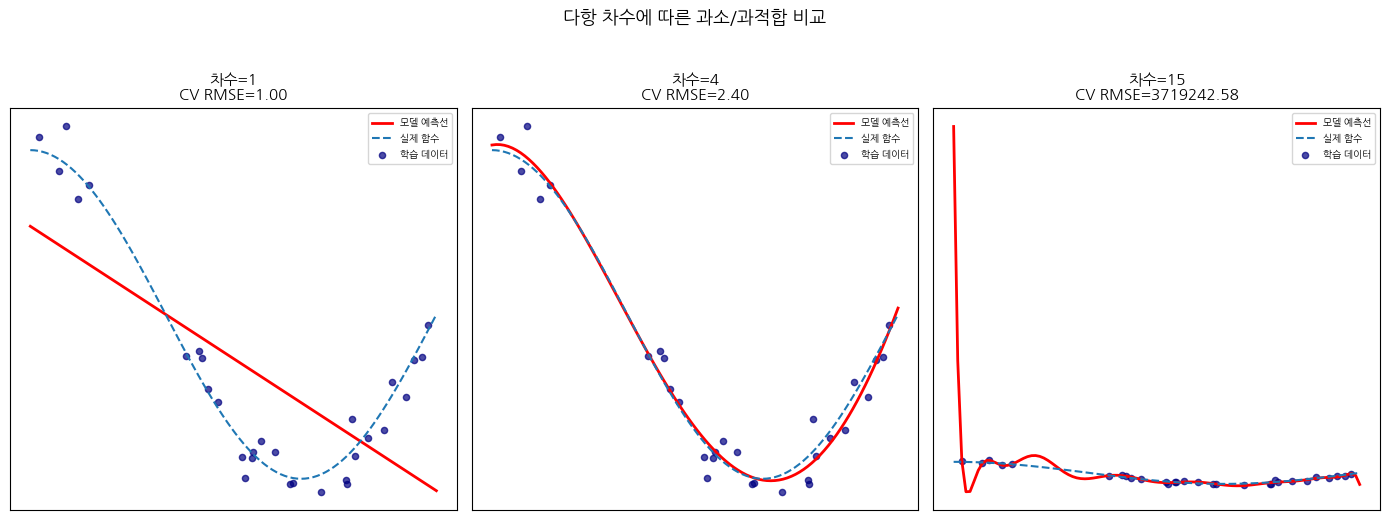

In [19]:
#다항 차수(degree)에 따른 과소/과적합 비교
def true_fun(X):
  return np.cos(1.5 * np.pi * X) #실제 비선형 함수(코사인 곡선)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples)) #0~1 범위 30개 정렬
y = true_fun(X) + np.random.randn(n_samples)*0.1 #노이즈 추가

plt.figure(figsize=(14,5))
degrees = [1,4,15] #비교할 3가지 차수
for i in range(len(degrees)):
  ax = plt.subplot(1,3,i+1)
  plt.setp(ax,xticks=(),yticks=()) #X축과 Y축 눈금 제거 세팅
  poly_features = PolynomialFeatures(degree=degrees[i],include_bias=False)
  linear_reg = LinearRegression()
  pipeline = Pipeline([
      ('poly',poly_features),
      ('linear',linear_reg)
  ])
  scores=cross_val_score(
      pipeline, X.reshape(-1,1),y,scoring='neg_mean_squared_error',cv=5
  )
  #예측선 시각화용: 0~1구간을 100개로 촘촘하게 분할
  X_test_plot = np.linspace(0,1,100).reshape(-1,1) #학습된 모델의 예측선을 그리기 위한 입력값
  pipeline.fit(X.reshape(-1,1),y)
  y_test_plot = pipeline.predict(X_test_plot)

  plt.plot(X_test_plot, y_test_plot, color='red', label='모델 예측선',linewidth=2)
  plt.plot(X_test_plot, true_fun(X_test_plot), label = '실제 함수',linestyle='--')
  plt.scatter(X,y,color='navy',s=20,alpha=0.7, label = '학습 데이터')

  rmse = np.sqrt(-scores.mean())
  ax.set_title(f'차수={degrees[i]}\nCV RMSE={rmse:.2f}',fontsize=11)
  ax.legend(fontsize=7)

plt.suptitle('다항 차수에 따른 과소/과적합 비교',fontsize=13,y=1.03)
plt.tight_layout()
plt.show()

### 규제 선형 모델 - 릿지(Ridge) / 라쏘(Lasso) / 엘라스틱넷

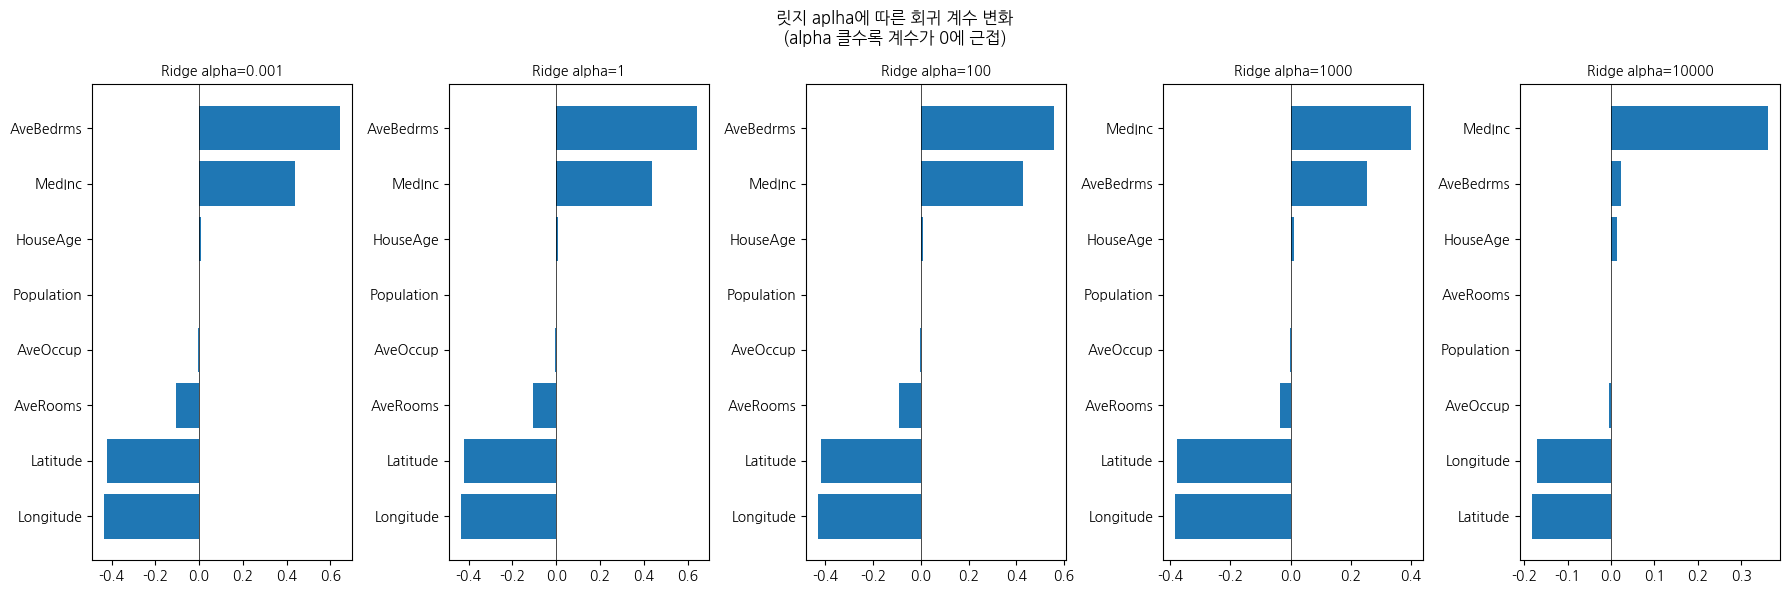


alpha별 회귀 계수 비교 (내림차순):
            alpha:0.001   alpha:1  alpha:100    alpha:1000  alpha:10000
AveBedrms      0.645065  0.644062   0.558249  2.522316e-01     0.022610
MedInc         0.436693  0.436594   0.428210  4.003862e-01     0.361897
HouseAge       0.009436  0.009437   0.009592  1.069611e-02     0.014055
Population    -0.000004 -0.000004  -0.000003  7.178537e-07     0.000014
AveOccup      -0.003787 -0.003786  -0.003773 -3.788927e-03    -0.004019
AveRooms      -0.107322 -0.107133  -0.091012 -3.579130e-02     0.000538
Latitude      -0.421314 -0.421299  -0.419061 -3.788068e-01    -0.181640
Longitude     -0.434514 -0.434485  -0.430993 -3.842308e-01    -0.170951


In [25]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
#릿지 회귀(Ridge Regression)
#alpha에 따른 회귀 계수 변화 시각화
alphas = [0.001, 1, 100, 1000, 10000]
fig, axs = plt.subplots(figsize=(18,6),nrows=1,ncols=5)
coeff_df = pd.DataFrame() #alpha별 계수를 하나의 DataFrame에 저장

for pos, alpha in enumerate(alphas):
  ridge = Ridge(alpha=alpha)
  ridge.fit(X_data, y_target)

  #각 피처의 회귀 계수를 Series로 변환
  coeff = pd.Series(data=ridge.coef_, index = X_data.columns)
  colname = f'alpha:{alpha}'
  coeff_df[colname] = coeff

  coeff_vals = coeff.sort_values(ascending = True)
  axs[pos].barh(y=coeff_vals.index, width=coeff_vals.values)
  axs[pos].set_title(f'Ridge alpha={alpha}',fontsize=10)
  axs[pos].axvline(0, color='black',linewidth=0.5) #0 기준선

plt.suptitle('릿지 aplha에 따른 회귀 계수 변화\n(alpha 클수록 계수가 0에 근접)', fontsize=12)
plt.tight_layout()
plt.show()

#alpha별 계수 비교 테이블
print('\nalpha별 회귀 계수 비교 (내림차순):')
sort_column = f'alpha:{alphas[0]}'
print(coeff_df.sort_values(by=sort_column, ascending=False))

In [41]:
#통합 평가 함수: Ridge / Lasso / ElasticNet 공통 사용
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None, verbose=True, return_coeff=True):
  coeff_df = pd.DataFrame()
  if verbose: print(f'{model_name}')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha=param)
    elif model_name == 'Lasso': model = Lasso(alpha=param)
    elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7) #L1(Lasso) 70% 과 L2(Ridge)30% 규제의 혼합 비율

    neg_mse = cross_val_score(model, X_data_n, y_target_n, scoring='neg_mean_squared_error', cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse))
    print(f'alpha={param}: 5-Fold 평균 RMSE={avg_rmse:.3f}')

    if return_coeff:
      model.fit(X_data_n, y_target_n) #전체 데이터로 회귀 계수 학습
      coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
      coeff_df[f'alpha:{param}'] = coeff

  return coeff_df

In [42]:
#라쏘 회귀(Lasso Regression)
lasso_alphas = [0.0005, 0.001, 0.003, 0.005, 0.01]

#캘리포니아 데이터셋의 경우 alpha가 너무 크면 대부분의 계수가 0이 되므로 더 작은 값 사용
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)
sort_column = f'alpha:{lasso_alphas[0]}'
print(coeff_lasso_df.sort_values(by=sort_column, ascending=False))
#alpha값이 커질수록 0이 되는 계수(피처) 수 증가 -> 자동 피처 선택

Lasso
alpha=0.0005: 5-Fold 평균 RMSE=0.746
alpha=0.001: 5-Fold 평균 RMSE=0.746
alpha=0.003: 5-Fold 평균 RMSE=0.746
alpha=0.005: 5-Fold 평균 RMSE=0.747
alpha=0.01: 5-Fold 평균 RMSE=0.749
            alpha:0.0005  alpha:0.001  alpha:0.003  alpha:0.005  alpha:0.01
AveBedrms       0.626528     0.607991     0.533831     0.459664    0.274245
MedInc          0.434851     0.433009     0.425640     0.418269    0.399842
HouseAge        0.009470     0.009504     0.009641     0.009777    0.010119
Population     -0.000004    -0.000004    -0.000003    -0.000003   -0.000001
AveOccup       -0.003779    -0.003771    -0.003741    -0.003711   -0.003636
AveRooms       -0.103773    -0.100224    -0.086025    -0.071824   -0.036322
Latitude       -0.420709    -0.420103    -0.417684    -0.415268   -0.409228
Longitude      -0.433624    -0.432734    -0.429179    -0.425626   -0.416745


In [43]:
#릿지 회귀(Ridge Regression)
ridge_alphas = [0.001, 1, 100, 1000, 10000]
coeff_ridge_df = get_linear_reg_eval('Ridge', params=ridge_alphas, X_data_n=X_data, y_target_n=y_target)
sort_column = f'alpha:{ridge_alphas[0]}'
print(coeff_ridge_df.sort_values(by=sort_column, ascending=False))

Ridge
alpha=0.001: 5-Fold 평균 RMSE=0.746
alpha=1: 5-Fold 평균 RMSE=0.746
alpha=100: 5-Fold 평균 RMSE=0.746
alpha=1000: 5-Fold 평균 RMSE=0.752
alpha=10000: 5-Fold 평균 RMSE=0.803
            alpha:0.001   alpha:1  alpha:100    alpha:1000  alpha:10000
AveBedrms      0.645065  0.644062   0.558249  2.522316e-01     0.022610
MedInc         0.436693  0.436594   0.428210  4.003862e-01     0.361897
HouseAge       0.009436  0.009437   0.009592  1.069611e-02     0.014055
Population    -0.000004 -0.000004  -0.000003  7.178537e-07     0.000014
AveOccup      -0.003787 -0.003786  -0.003773 -3.788927e-03    -0.004019
AveRooms      -0.107322 -0.107133  -0.091012 -3.579130e-02     0.000538
Latitude      -0.421314 -0.421299  -0.419061 -3.788068e-01    -0.181640
Longitude     -0.434514 -0.434485  -0.430993 -3.842308e-01    -0.170951


In [45]:
#엘라스틱넷 회귀(ElasticNet Regression) : L1 + L2 혼합 규제
#Lasso의 피처 선택 + Ridge의 안정성을 동시에 활용
#피처 수가 샘플보다 많을 때 (고차원 데이터), 상관관계 높은 피처가 여러 개 있을 때, Lasso는 그 중 하나만 선택, ElasticNet은 그룹으로 선택
elastic_alphas = [0.0005, 0.001, 0.003, 0.005, 0.01]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_data_n=X_data, y_target_n=y_target)
sort_column = f'alpha:{elastic_alphas[0]}'
print(coeff_elastic_df.sort_values(by=sort_column,ascending=False))

ElasticNet
alpha=0.0005: 5-Fold 평균 RMSE=0.746
alpha=0.001: 5-Fold 평균 RMSE=0.746
alpha=0.003: 5-Fold 평균 RMSE=0.746
alpha=0.005: 5-Fold 평균 RMSE=0.746
alpha=0.01: 5-Fold 평균 RMSE=0.748
            alpha:0.0005  alpha:0.001  alpha:0.003  alpha:0.005  alpha:0.01
AveBedrms       0.629057     0.613202     0.551281     0.491656    0.351836
MedInc          0.435105     0.433534     0.427402     0.421509    0.407736
HouseAge        0.009465     0.009493     0.009608     0.009722    0.010002
Population     -0.000004    -0.000004    -0.000003    -0.000003   -0.000002
AveOccup       -0.003781    -0.003775    -0.003752    -0.003731   -0.003679
AveRooms       -0.104266    -0.101240    -0.089424    -0.078054   -0.051418
Latitude       -0.420840    -0.420357    -0.418344    -0.416209   -0.410385
Longitude      -0.433798    -0.433075    -0.430117    -0.427059   -0.419015


In [51]:
#데이터 스케일링 방법에 따른 릿지 성능 비교
#피처 단위가 다르면 큰 단위 피처의 계수가 작아지는 불공평 발생
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
def get_scaled_data(method='None', p_degree=None, input_data=None):
  if method == 'Standard': scale_data = StandardScaler().fit_transform(input_data)
  elif method == 'MinMax': scale_data = MinMaxScaler().fit_transform(input_data)
  elif method == 'Log': scale_data = np.log1p(np.maximum(0, input_data)) #음수값을 0으로 클리핑하여 NaN 발생 방지
  else: scale_data = input_data

  if p_degree is not None: #스케일링 수 다항식 피처 추가
    scale_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scale_data)
  return scale_data

alphas = [0.01, 0.1, 1, 10]
scale_methods = [
    (None,None),
    ('Standard',None),
    ('Standard',2), #표준화 + 2차 다항(비선형 패턴 포착)
    ('MinMax',None),
    ('MinMax',2),
    ('Log',None),
    ('Log',2)]
print('데이터 변환 방법 × alpha에 따른 릿지 RMSE')
for scale_method in scale_methods:
  X_scaled = get_scaled_data(
      method = scale_method[0],
      p_degree = scale_method[1],
      input_data = X_data
  )
  print(f'\n변환: {scale_method[0]}, 다항={scale_method[1]}, 피처 shape={X_scaled.shape}')
  for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    neg_mse = cross_val_score(ridge, X_scaled, y_target, scoring='neg_mean_squared_error',cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse))
    print(f'alpha={alpha:5}:RMSE={avg_rmse:.3f}')

데이터 변환 방법 × alpha에 따른 릿지 RMSE

변환: None, 다항=None, 피처 shape=(20640, 8)
alpha= 0.01:RMSE=0.746
alpha=  0.1:RMSE=0.746
alpha=    1:RMSE=0.746
alpha=   10:RMSE=0.746

변환: Standard, 다항=None, 피처 shape=(20640, 8)
alpha= 0.01:RMSE=0.746
alpha=  0.1:RMSE=0.746
alpha=    1:RMSE=0.746
alpha=   10:RMSE=0.746

변환: Standard, 다항=2, 피처 shape=(20640, 44)
alpha= 0.01:RMSE=3.380
alpha=  0.1:RMSE=3.323
alpha=    1:RMSE=2.850
alpha=   10:RMSE=1.314

변환: MinMax, 다항=None, 피처 shape=(20640, 8)
alpha= 0.01:RMSE=0.746
alpha=  0.1:RMSE=0.745
alpha=    1:RMSE=0.748
alpha=   10:RMSE=0.754

변환: MinMax, 다항=2, 피처 shape=(20640, 44)
alpha= 0.01:RMSE=0.729
alpha=  0.1:RMSE=0.726
alpha=    1:RMSE=0.742
alpha=   10:RMSE=0.755

변환: Log, 다항=None, 피처 shape=(20640, 8)
alpha= 0.01:RMSE=0.777
alpha=  0.1:RMSE=0.777
alpha=    1:RMSE=0.777
alpha=   10:RMSE=0.777

변환: Log, 다항=2, 피처 shape=(20640, 44)
alpha= 0.01:RMSE=0.710
alpha=  0.1:RMSE=0.709
alpha=    1:RMSE=0.707
alpha=   10:RMSE=0.706
